In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('gender_classification_v7.csv')

print(f"Shape: {df.shape}")
print(df.head())

Shape: (5001, 8)
   long_hair  forehead_width_cm  forehead_height_cm  nose_wide  nose_long  \
0          1               11.8                 6.1          1          0   
1          0               14.0                 5.4          0          0   
2          0               11.8                 6.3          1          1   
3          0               14.4                 6.1          0          1   
4          1               13.5                 5.9          0          0   

   lips_thin  distance_nose_to_lip_long  gender  
0          1                          1    Male  
1          1                          0  Female  
2          1                          1    Male  
3          1                          1    Male  
4          0                          0  Female  


In [2]:
X = df.drop(['gender'], axis=1)
y = df['gender']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(y_train)

Train: 4000, Test: 1001
4677      Male
800     Female
3671    Female
4193    Female
2968      Male
         ...  
4426    Female
466     Female
3092    Female
3772    Female
860     Female
Name: gender, Length: 4000, dtype: object


In [5]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
print(y_pred_test)
acc = accuracy_score(y_test, y_pred_test)

print(f"Test Accuracy: {acc:.4f}")

['Male' 'Female' 'Female' ... 'Female' 'Male' 'Female']
Test Accuracy: 0.9610


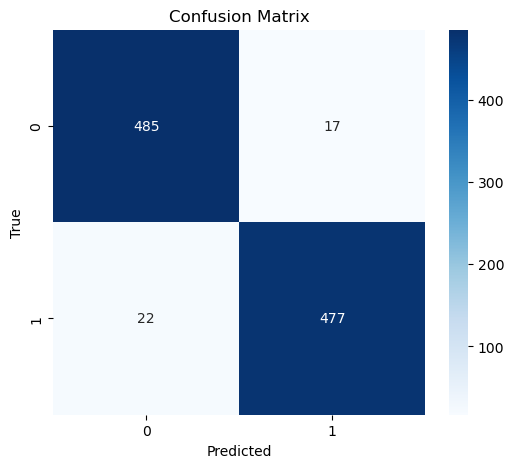

Confusion Matrix:
[[485  17]
 [ 22 477]]


In [4]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(f"Confusion Matrix:\n{cm}")